
🔷 STEP 1: REQUIRED LIBRARIES

In [3]:
!pip install numpy scipy matplotlib pandas

In [4]:
pip install tensorflow

🔷 STEP 2: PROJECT FLOW IN PYTHON

In [5]:
#PMSM Simulation → Flux Estimation → Thermal Model → Comparison → (Later EKF + AI)#

🔷 STEP 3: BUILD MODULE BY MODULE

In [6]:
#🧩 3.1 PMSM SIGNAL GENERATION

In [75]:
import numpy as np

t = np.linspace(0, 10, 1000)

omega = np.piecewise(t,
    [t < 3, (t >= 3) & (t < 7), t >= 7],
    [50, 200, 100]
)   # speed variation
id = 2*np.sin(t)
iq = 5*np.cos(t)

Rs = 0.5
Ld = 0.01
Lq = 0.01
psi_true = 0.1

In [76]:
#🧩 3.2 ADD TEMPERATURE EFFECT

In [77]:
alpha = -0.0011
T_ref = 25

T_true = 25 + 50*(1 - np.exp(-t/5))  # rising temp

psi_actual = psi_true * (1 + alpha*(T_true - T_ref))

In [78]:
#🧩 3.3 GENERATE VOLTAGES

In [79]:
vd = Rs*id + Ld*np.gradient(id, t) - omega*Lq*iq
vq = Rs*iq + Lq*np.gradient(iq, t) + omega*(Ld*id + psi_actual)

In [80]:
#🧩 3.4 FLUX ESTIMATION

In [81]:
psi_est = (vq - Rs*iq - omega*Ld*id) / omega

In [82]:
#🧩 3.5 TEMPERATURE ESTIMATION

In [83]:
T_est_flux = T_ref + (psi_est - psi_true) / (alpha * psi_true)

In [84]:
#🧩 3.6 THERMAL MODEL

In [85]:
T_amb = 25
R_th = 2
C_th = 100

T_thermal = np.zeros_like(t)
T_thermal[0] = 25

for i in range(1, len(t)):
    P_loss = 0.5*(id[i]**2 + iq[i]**2)

    dT = (P_loss - (T_thermal[i-1] - T_amb)/2)/50
    T_thermal[i] = T_thermal[i-1] + dT

In [86]:
#📊 3.7 PLOT RESULTS

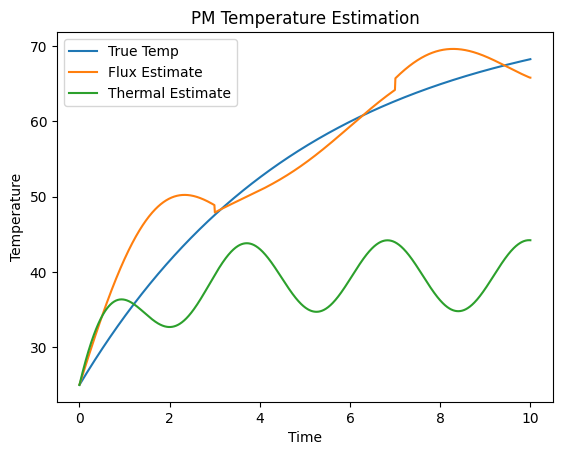

In [87]:
import matplotlib.pyplot as plt

plt.plot(t, T_true, label="True Temp")
plt.plot(t, T_est_flux, label="Flux Estimate")
plt.plot(t, T_thermal, label="Thermal Estimate")

plt.legend()
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("PM Temperature Estimation")

plt.show()

In [88]:
#NOISE Addition
noise = np.random.normal(0, 0.01, size=len(vq))
vq_noisy = vq + noise

In [89]:
#🚀 PYTHON EKF CODE

In [90]:
import numpy as np

# ---------- INITIALIZATION ----------
n = len(T_true)

# State estimate
x_est = np.zeros(n)

# Initial guess
x_est[0] = 25

# Covariance
P = 1.0

# Process noise (tune this)
Q = 0.05

# Measurement noise (tune these)
R_flux = 2.0
R_thermal = 20.0   # thermal estimate noise

# ---------- EKF LOOP ----------
for k in range(1, n):

    # ---------- PREDICTION ----------
    x_pred = x_est[k-1]      # x_k = x_k-1
    P_pred = P + Q

    # ---------- UPDATE 1 (Flux) ----------
    z1 = T_est_flux[k]

    K1 = P_pred / (P_pred + R_flux)
    x_upd1 = x_pred + K1 * (z1 - x_pred)
    P_upd1 = (1 - K1) * P_pred

    # ---------- UPDATE 2 (Thermal) ----------
    z2 = T_thermal[k]

    K2 = P_upd1 / (P_upd1 + R_thermal)
    x_upd2 = x_upd1 + K2 * (z2 - x_upd1)
    P = (1 - K2) * P_upd1

    # Save result
    x_est[k] = x_upd2

# Final output
T_EKF = x_est

In [92]:
T_est_flux += np.random.normal(0, 2, size=len(t))

In [93]:
R_flux = 10 / (omega[k] + 1)

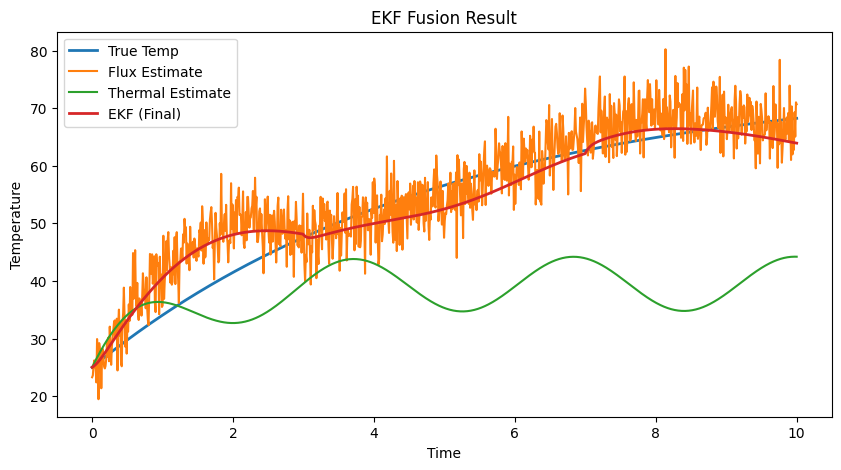

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(t, T_true, label="True Temp", linewidth=2)
plt.plot(t, T_est_flux, label="Flux Estimate")
plt.plot(t, T_thermal, label="Thermal Estimate")
plt.plot(t, T_EKF, label="EKF (Final)", linewidth=2)

plt.legend()
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("EKF Fusion Result")

plt.show()

In [109]:
#NEXT STEP 4: ADD ERROR GRAPH

Text(0.5, 1.0, 'EKF Error')

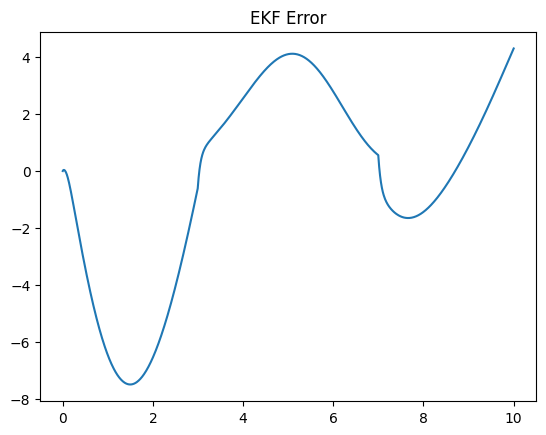

In [110]:
error = T_true - T_EKF

plt.plot(t, error)
plt.title("EKF Error")

In [111]:
#🚀 2. ADD NEURAL NETWORK

In [113]:
from sklearn.neural_network import MLPRegressor

# Input features
X = np.column_stack((T_EKF, omega, id, iq, T_thermal))

# Target
y = T_true - T_EKF

# Train model
model = MLPRegressor(hidden_layer_sizes=(16,16), max_iter=500)
model.fit(X, y)

# Prediction
correction = model.predict(X)

# Final temperature
T_final = T_EKF + correction

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.



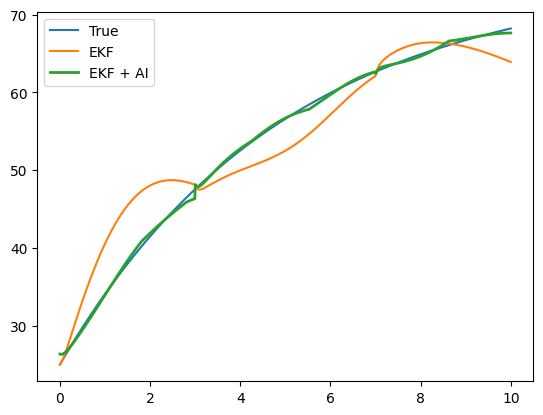

In [114]:
plt.plot(t, T_true, label="True")
plt.plot(t, T_EKF, label="EKF")
plt.plot(t, T_final, label="EKF + AI", linewidth=2)
plt.legend()

In [115]:
#ERROR GRAPH

Text(0.5, 1.0, 'Error Comparison')

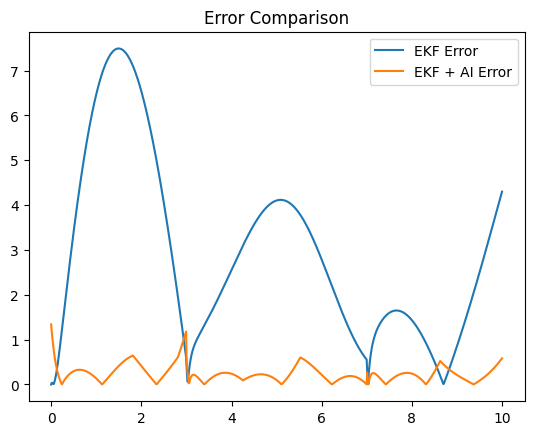

In [116]:
error_ekf = abs(T_true - T_EKF)
error_ai = abs(T_true - T_final)

plt.plot(t, error_ekf, label="EKF Error")
plt.plot(t, error_ai, label="EKF + AI Error")
plt.legend()
plt.title("Error Comparison")

In [117]:
#CALCULATE METRICS

In [118]:
from sklearn.metrics import mean_squared_error

rmse_ekf = np.sqrt(mean_squared_error(T_true, T_EKF))
rmse_ai = np.sqrt(mean_squared_error(T_true, T_final))

print("EKF RMSE:", rmse_ekf)
print("AI RMSE:", rmse_ai)

EKF RMSE: 3.5526585656837675
AI RMSE: 0.3094669148290387


In [119]:
#4.3 ADD NOISE TEST (ADVANCED)

In [120]:
T_est_flux += np.random.normal(0, 3, size=len(t))

In [121]:
#4.4 ADD SPEED VARIATION (REALISM)

In [107]:
omega = np.piecewise(t,
    [t < 3, (t >= 3) & (t < 7), t >= 7],
    [50, 200, 100]
)